# Initialization Scale Ablation: Figure 4 Left

This notebook plots the excess validation loss for the minimal architecture under different query initialization scales. It uses the `ICLR-Fig1` W&B tag, the same sweep that produced the minimal-model staged-learning runs.


In [1]:
from analysis.utils import differing_config, fetch_runs, get_runs_data
import matplotlib.pyplot as plt
import pandas as pd


SAVE_FIGURES = False


def output_path(name):
    return f"analysis/figures/{name}" if SAVE_FIGURES else None


In [2]:
runs = fetch_runs(tags_any=["ICLR-Fig1"])
df = get_runs_data(runs, metrics=["val_loss", "teacher_val_loss"])
differing_config(df.drop(columns=["cfg.teacher.span_lengths"], errors="ignore"))


,_run_id,_run_name,cfg.ngrams.bigram.query_init_scale,cfg.ngrams.bigram.value_init_scale,cfg.ngrams.trigram.query_init_scale,cfg.ngrams.trigram.value_init_scale,cfg.ngrams.unigram.query_init_scale,cfg.ngrams.unigram.value_init_scale,cfg.student.query_init_scale,cfg.student.value_init_scale
0,dayi1xj5,fearless-capybara-1686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,hhfk9daj,hearty-puddle-1679,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0
2,i0a1de0a,apricot-paper-1676,1.000000e-09,0.0,1.000000e-09,0.0,1.000000e-09,0.0,1.000000e-09,0.0
3,iai8ang2,decent-gorge-1677,1.000000e-06,0.0,1.000000e-06,0.0,1.000000e-06,0.0,1.000000e-06,0.0
4,xy9noxwc,cool-eon-1677,1.000000e-03,0.0,1.000000e-03,0.0,1.000000e-03,0.0,1.000000e-03,0.0


## Figure 4 Left: Excess Loss By Query Initialization

Subtracting the teacher loss makes the staged optimization behavior comparable across runs.


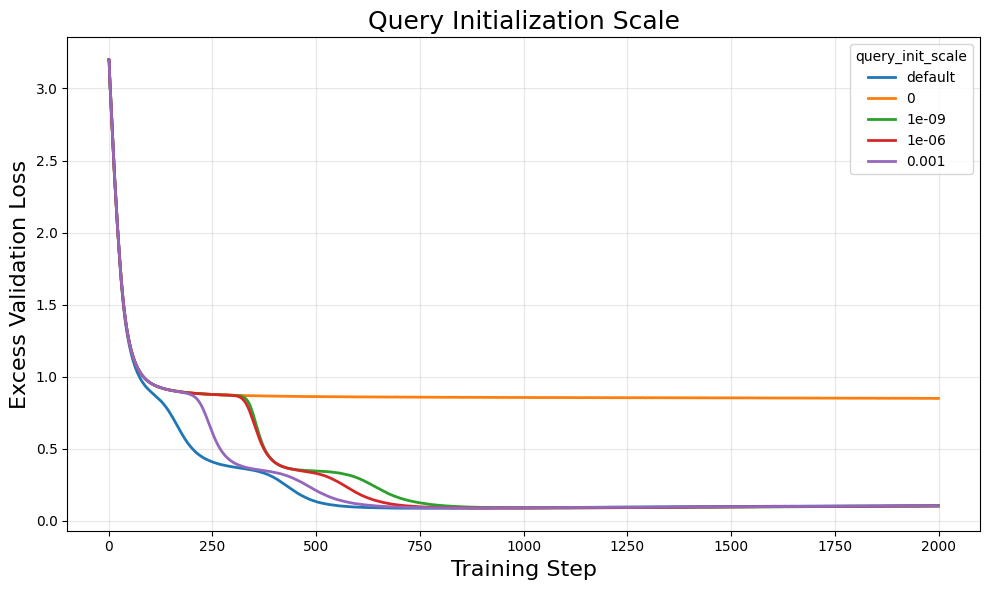

In [3]:
teacher_val_loss = df["teacher_val_loss"].dropna().unique()[0]

fig, ax = plt.subplots(figsize=(10, 6))
groups = df.groupby(["_run_name", "cfg.student.query_init_scale"], dropna=False)["val_loss"]


def sort_key(item):
    scale = item[0][1]
    return (0, 0) if pd.isna(scale) else (1, float(scale))

for (_, scale), values in sorted(groups, key=sort_key):
    label = "default" if pd.isna(scale) else f"{scale:g}"
    ax.plot(values.to_numpy() - teacher_val_loss, label=label, linewidth=2)

ax.set_xlabel("Training Step", fontsize=16)
ax.set_ylabel("Excess Validation Loss", fontsize=16)
ax.set_title("Query Initialization Scale", fontsize=18)
ax.grid(True, alpha=0.3)
ax.legend(title="query_init_scale")
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(output_path("init-scales-excess-loss.pdf"), bbox_inches="tight", dpi=300)
else:
    plt.show()
